# Power Electronics: Rectifiers and DC-DC Converters, Derived and Verified

Two workhorses power every device you own. RECTIFIERS turn AC into DC by
letting current pass only one way; averaging the rectified sinusoid gives
the DC output, and how much it still wiggles is the RIPPLE. DC-DC
CONVERTERS trade voltage for current by switching an inductor at duty
cycle $D$; steady-state volt-second balance across the inductor fixes the
output voltage. Every closed form below is derived symbolically with
SymPy, cross-checked against an independent numerical calculation (a
direct time-domain average for the rectifiers, volt-second balance for
the converters), then swept over realistic design parameters. Engine:
`dgs/power_electronics.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import power_electronics as pe

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Rectifiers: Deriving $V_{dc}$ and $V_{rms}$ from First Principles

A rectified sinusoid $v(t)=V_p\sin(\omega t)$ over one period: HALF-WAVE
keeps only the positive lobe, FULL-WAVE flips the negative lobe on top of
the positive one. $V_{dc}$ is the time-average, $V_{rms}$ is the
root-mean-square -- both derived here as SymPy integrals over one period,
not quoted from a table.


In [2]:
t, w, Vp = sp.symbols('t omega V_p', positive=True)
v = Vp * sp.sin(w * t)
T = 2*sp.pi/w   # one period

# half-wave: v(t) for 0<t<T/2 (positive lobe), 0 for T/2<t<T
Vdc_half = sp.integrate(v, (t, 0, sp.pi/w)) / T
Vdc_half = sp.simplify(Vdc_half)
print('half-wave V_dc = (1/T) * integral of v dt over the positive lobe =', Vdc_half)

Vrms_half_sq = sp.integrate(v**2, (t, 0, sp.pi/w)) / T
Vrms_half = sp.sqrt(sp.simplify(Vrms_half_sq))
print('half-wave V_rms = sqrt((1/T) * integral of v^2 dt over the positive lobe) =', Vrms_half)


half-wave V_dc = (1/T) * integral of v dt over the positive lobe = V_p/pi
half-wave V_rms = sqrt((1/T) * integral of v^2 dt over the positive lobe) = V_p/2


In [3]:
# full-wave: |v(t)| over the FULL period (both lobes flipped positive)
Vdc_full = sp.integrate(sp.Abs(v), (t, 0, T)) / T
Vdc_full = sp.simplify(Vdc_full)
print('full-wave V_dc = (1/T) * integral of |v| dt over a full period =', Vdc_full)

Vrms_full_sq = sp.integrate(v**2, (t, 0, T)) / T
Vrms_full = sp.sqrt(sp.simplify(Vrms_full_sq))
print('full-wave V_rms = sqrt((1/T) * integral of v^2 dt over a full period) =', Vrms_full)

print(f'\nfull-wave delivers {float(Vdc_full/Vdc_half):.4f}x the DC of half-wave (expect exactly 2)')


full-wave V_dc = (1/T) * integral of |v| dt over a full period = 2*V_p/pi
full-wave V_rms = sqrt((1/T) * integral of v^2 dt over a full period) = sqrt(2)*V_p/2

full-wave delivers 2.0000x the DC of half-wave (expect exactly 2)


## 2. Ripple Factor, and a Numeric Cross-Check

The RIPPLE FACTOR $r=\sqrt{(V_{rms}/V_{dc})^2-1}$ measures the AC content
left relative to the DC level (0 = perfectly flat). Cross-checking the
closed forms above against a direct NUMERICAL time-average of the
rectified wave -- an independent calculation, not the same integral
reused.


In [4]:
Vp_val = 170.0   # ~120 Vrms mains peak

hw = pe.halfwave_rectifier(Vp_val)
fw = pe.fullwave_rectifier(Vp_val)
print(f'rectifying {Vp_val} V peak (120 Vrms mains):')
print(f"  half-wave: V_dc={hw['v_dc']:.2f} V, V_rms={hw['v_rms']:.2f} V, ripple factor={hw['ripple_factor']:.4f}")
print(f"  full-wave: V_dc={fw['v_dc']:.2f} V, V_rms={fw['v_rms']:.2f} V, ripple factor={fw['ripple_factor']:.4f}")

dc_numeric, rms_numeric = pe.rectifier_numeric(Vp_val, full_wave=True)
print(f"\nnumeric full-wave check (direct time-domain average): V_dc={dc_numeric:.4f}, V_rms={rms_numeric:.4f}")
print(f"matches closed form: V_dc {abs(dc_numeric-fw['v_dc'])<1e-6}, V_rms {abs(rms_numeric-fw['v_rms'])<1e-6}")

# also confirm the symbolic derivation above matches these same numbers
Vdc_half_numeric = float(Vdc_half.subs({Vp: Vp_val}))
Vdc_full_numeric = float(Vdc_full.subs({Vp: Vp_val}))
print(f"\nsymbolic derivation matches module: half-wave {abs(Vdc_half_numeric-hw['v_dc'])<1e-9}, "
      f"full-wave {abs(Vdc_full_numeric-fw['v_dc'])<1e-9}")


rectifying 170.0 V peak (120 Vrms mains):
  half-wave: V_dc=54.11 V, V_rms=85.00 V, ripple factor=1.2114
  full-wave: V_dc=108.23 V, V_rms=120.21 V, ripple factor=0.4834

numeric full-wave check (direct time-domain average): V_dc=108.2254, V_rms=120.2082
matches closed form: V_dc True, V_rms True

symbolic derivation matches module: half-wave True, full-wave True


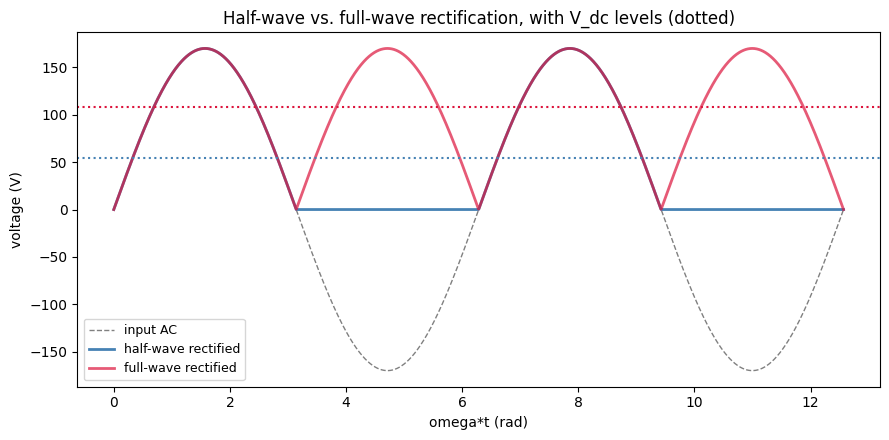

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
t_plot = np.linspace(0, 4*np.pi, 2000)
v_plot = Vp_val * np.sin(t_plot)
ax.plot(t_plot, v_plot, color='gray', lw=1, ls='--', label='input AC')
ax.plot(t_plot, np.maximum(v_plot, 0), color='steelblue', lw=2, label='half-wave rectified')
ax.plot(t_plot, np.abs(v_plot), color='crimson', lw=2, alpha=0.7, label='full-wave rectified')
ax.axhline(hw['v_dc'], color='steelblue', ls=':', lw=1.5)
ax.axhline(fw['v_dc'], color='crimson', ls=':', lw=1.5)
ax.set_xlabel('omega*t (rad)'); ax.set_ylabel('voltage (V)')
ax.set_title('Half-wave vs. full-wave rectification, with V_dc levels (dotted)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('power_electronics_rectifier_waveforms.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. DC-DC Converters: Deriving $V_{out}$ from Volt-Second Balance

In steady state, the average voltage across an inductor over one
switching period must be exactly zero (otherwise its current would ramp
away without bound) -- this is VOLT-SECOND BALANCE. For a BUCK converter,
the inductor sees $V_{in}-V_{out}$ for the ON-time $DT$ and $-V_{out}$ for
the OFF-time $(1-D)T$:
$$(V_{in}-V_{out})DT + (-V_{out})(1-D)T = 0\ \Rightarrow\ V_{out}=DV_{in}.$$
For a BOOST converter, the inductor sees $V_{in}$ for $DT$ and
$V_{in}-V_{out}$ for $(1-D)T$:
$$V_{in}DT+(V_{in}-V_{out})(1-D)T=0\ \Rightarrow\ V_{out}=\frac{V_{in}}{1-D}.$$


In [6]:
Vin, Vout, D, Tsw = sp.symbols('V_in V_out D T', positive=True)

# buck: volt-second balance, (Vin-Vout)*D*T + (-Vout)*(1-D)*T = 0
buck_balance = sp.Eq((Vin - Vout)*D*Tsw + (-Vout)*(1-D)*Tsw, 0)
Vout_buck = sp.solve(buck_balance, Vout)[0]
print('buck volt-second balance:', buck_balance)
print('  => V_out =', Vout_buck, '  (matches D*V_in:', sp.simplify(Vout_buck - D*Vin) == 0, ')')

# boost: Vin*D*T + (Vin-Vout)*(1-D)*T = 0
boost_balance = sp.Eq(Vin*D*Tsw + (Vin - Vout)*(1-D)*Tsw, 0)
Vout_boost = sp.solve(boost_balance, Vout)[0]
print('\nboost volt-second balance:', boost_balance)
print('  => V_out =', sp.simplify(Vout_boost), '  (matches V_in/(1-D):',
      sp.simplify(Vout_boost - Vin/(1-D)) == 0, ')')


buck volt-second balance:

 Eq(D*T*(V_in - V_out) - T*V_out*(1 - D), 0)
  => V_out = D*V_in   (matches D*V_in: True )

boost volt-second balance: Eq(D*T*V_in + T*(1 - D)*(V_in - V_out), 0)
  => V_out = -V_in/(D - 1)   (matches V_in/(1-D): True )


In [7]:
D_val = 0.5
Vin_val = 12.0
print(f'DC-DC converters from {Vin_val} V at D={D_val}:')
print(f"  buck       -> {pe.buck_output(Vin_val, D_val):.2f} V (step down)")
print(f"  boost      -> {pe.boost_output(Vin_val, D_val):.2f} V (step up)")
print(f"  buck-boost -> {pe.buck_boost_output(Vin_val, D_val):.2f} V (inverted)")

target_out = 5.0
D_needed = pe.duty_for_buck(Vin_val, target_out)
print(f"\nto make {target_out} V from {Vin_val} V, a buck needs D = {D_needed:.4f}")
print(f"round-trip check: buck_output(D={D_needed:.4f}) = {pe.buck_output(Vin_val, D_needed):.4f} V")


DC-DC converters from 12.0 V at D=0.5:
  buck       -> 6.00 V (step down)
  boost      -> 24.00 V (step up)
  buck-boost -> -12.00 V (inverted)

to make 5.0 V from 12.0 V, a buck needs D = 0.4167
round-trip check: buck_output(D=0.4167) = 5.0000 V


## 4. Buck and Boost Output vs. Duty Cycle

Sweeping $D$ across its full $(0,1)$ range shows the buck's linear
transfer characteristic against the boost's diverging one as $D\to1$
(theoretically unbounded step-up, a real converter is limited by
component losses long before that).


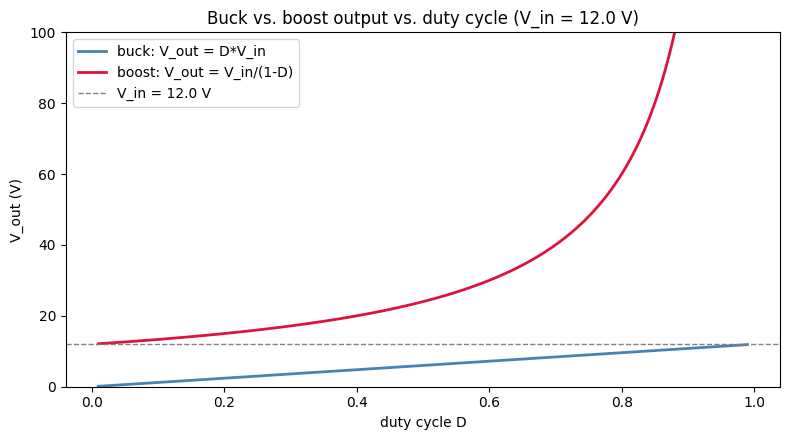

In [8]:
D_sweep = np.linspace(0.01, 0.99, 200)
buck_curve = [pe.buck_output(Vin_val, d) for d in D_sweep]
boost_curve = [pe.boost_output(Vin_val, d) for d in D_sweep]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(D_sweep, buck_curve, color='steelblue', lw=2, label='buck: V_out = D*V_in')
ax.plot(D_sweep, boost_curve, color='crimson', lw=2, label='boost: V_out = V_in/(1-D)')
ax.axhline(Vin_val, color='gray', ls='--', lw=1, label=f'V_in = {Vin_val} V')
ax.set_xlabel('duty cycle D'); ax.set_ylabel('V_out (V)')
ax.set_ylim(0, 100)
ax.set_title(f'Buck vs. boost output vs. duty cycle (V_in = {Vin_val} V)')
ax.legend()
plt.tight_layout()
plt.savefig('power_electronics_duty_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Switching Ripple: Inductor Current and Output Voltage

Every real converter leaves residual ripple. During the buck's ON-time
$D/f_{sw}$ the inductor sees $V_{in}-V_{out}=V_{in}(1-D)$, giving
peak-to-peak ripple current
$$\Delta I=\frac{V_{in}(1-D)D}{Lf_{sw}},$$
and the output capacitor smooths this to a residual voltage ripple
$\Delta V=\Delta I/(8Cf_{sw})$. Sweeping switching frequency and
inductance shows the classic power-electronics trade: faster switching or
bigger passives both shrink ripple, at a cost (switching loss, size).


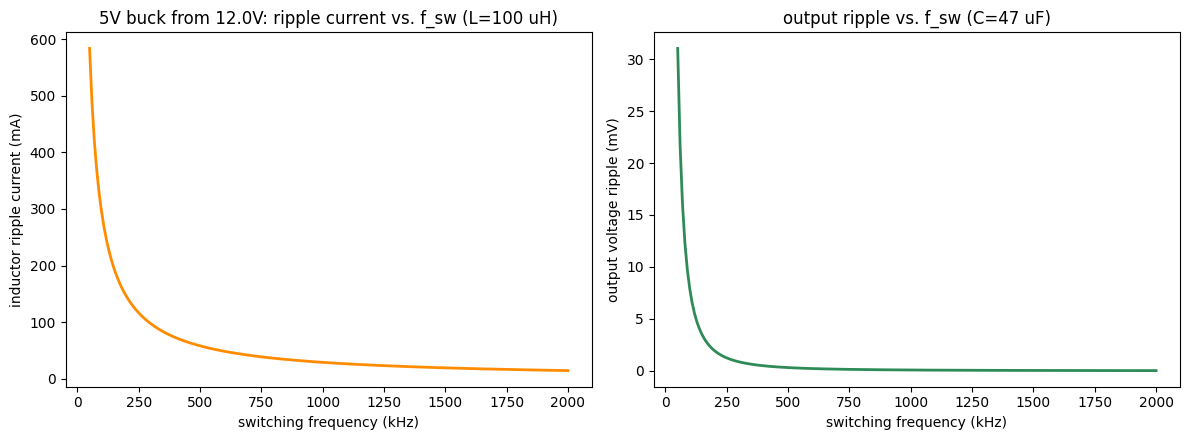

at 500 kHz: inductor ripple = 58.33 mA, output ripple = 0.3103 mV


In [9]:
L_val, C_val = 100e-6, 47e-6   # 100 uH, 47 uF
fsw_sweep = np.linspace(50e3, 2e6, 200)   # 50 kHz to 2 MHz
D_5V = pe.duty_for_buck(Vin_val, 5.0)

dI_vs_fsw = [pe.inductor_ripple_current(Vin_val, D_5V, L_val, f, topology='buck') for f in fsw_sweep]
dV_vs_fsw = [pe.output_voltage_ripple(dI, C_val, f) for dI, f in zip(dI_vs_fsw, fsw_sweep)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fsw_sweep/1e3, np.array(dI_vs_fsw)*1e3, color='darkorange', lw=2)
axes[0].set_xlabel('switching frequency (kHz)'); axes[0].set_ylabel('inductor ripple current (mA)')
axes[0].set_title(f'5V buck from {Vin_val}V: ripple current vs. f_sw (L={L_val*1e6:.0f} uH)')

axes[1].plot(fsw_sweep/1e3, np.array(dV_vs_fsw)*1e3, color='seagreen', lw=2)
axes[1].set_xlabel('switching frequency (kHz)'); axes[1].set_ylabel('output voltage ripple (mV)')
axes[1].set_title(f'output ripple vs. f_sw (C={C_val*1e6:.0f} uF)')
plt.tight_layout()
plt.savefig('power_electronics_ripple_vs_fsw.png', dpi=100, bbox_inches='tight')
plt.show()

dI_500k = pe.inductor_ripple_current(Vin_val, D_5V, L_val, 500e3, topology='buck')
dV_500k = pe.output_voltage_ripple(dI_500k, C_val, 500e3)
print(f'at 500 kHz: inductor ripple = {dI_500k*1e3:.2f} mA, output ripple = {dV_500k*1e3:.4f} mV')


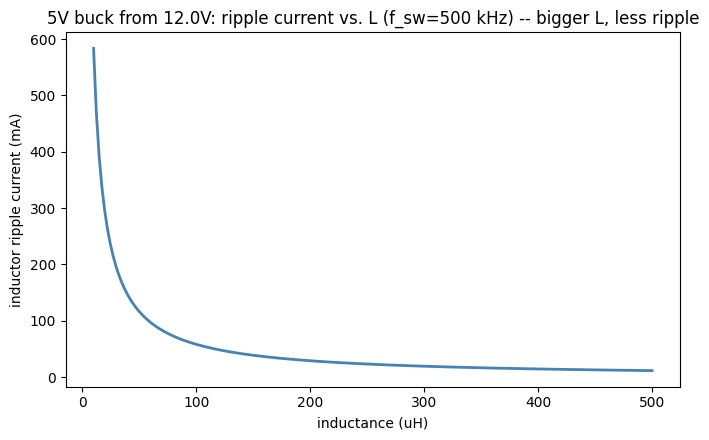

In [10]:
L_sweep = np.linspace(10e-6, 500e-6, 200)   # 10 uH to 500 uH
dI_vs_L = [pe.inductor_ripple_current(Vin_val, D_5V, L, 500e3, topology='buck') for L in L_sweep]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(L_sweep*1e6, np.array(dI_vs_L)*1e3, color='steelblue', lw=2)
ax.set_xlabel('inductance (uH)'); ax.set_ylabel('inductor ripple current (mA)')
ax.set_title(f'5V buck from {Vin_val}V: ripple current vs. L (f_sw=500 kHz) -- bigger L, less ripple')
plt.tight_layout()
plt.savefig('power_electronics_ripple_vs_L.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Converter Efficiency

$\eta=P_{out}/P_{in}$; the rest is switching and conduction loss. A
quick worked example: the 5V/100uH/500kHz buck above delivering some load
current, with a representative (not derived -- a real value needs a full
loss model) power budget.


In [11]:
P_out_example = 5.0 * 1.0    # 5V * 1A load
P_in_example = 5.5           # representative: some conduction + switching loss on top of P_out
eta = pe.efficiency(P_out_example, P_in_example)
print(f'P_out = {P_out_example} W, P_in = {P_in_example} W -> efficiency = {eta*100:.1f}%')


P_out = 5.0 W, P_in = 5.5 W -> efficiency = 90.9%


## 7. Engineering Interpretation

- Section 1's derivation confirms the textbook factor of exactly 2
  between full-wave and half-wave $V_{dc}$ symbolically, not just as a
  memorized ratio -- and section 2's independent numeric time-average
  cross-check catches any sign/limits error the integral setup could hide.
- Section 3's volt-second-balance derivation is the SAME physical
  principle (zero net inductor voltage over a period, in steady state)
  producing both the buck's linear and the boost's divergent transfer
  characteristic -- one governing equation, two different circuit
  topologies for which terms appear in it.
- Section 4's boost curve blowing up as $D\to1$ is a real design warning,
  not just a mathematical curiosity: practical boost converters cap duty
  cycle well below 1, because parasitic resistances (not modeled here)
  make the ACTUAL gain saturate and then fall as loss dominates.
- Section 5's two ripple sweeps show the standard converter-design lever:
  faster switching or a bigger inductor both cut ripple current, but
  faster switching raises switching LOSS and a bigger inductor raises
  size/cost -- the closed forms make that trade quantitative instead of
  qualitative.


## 8. Research Discussion

- Section 6's efficiency example used a REPRESENTATIVE loss number, not a
  derived one -- could `dgs/power_electronics.py` be extended with an
  explicit conduction-loss model ($I_{rms}^2R_{DS(on)}$ for the switch,
  ESR losses in $L$ and $C$) so efficiency becomes a genuine prediction
  rather than an assumed input?
- The boost converter's real-world efficiency collapse near $D\to1$ (not
  modeled here) is a classic power-electronics result -- would adding a
  simple parasitic-resistance term to `boost_output`'s derivation and
  re-deriving the ACTUAL (not ideal) transfer characteristic make a
  compelling continuation of section 4?
- Could `dgs/em_lagrangian_action.py` or `dgs/lagrangian_circuits.py`'s
  energy-methods machinery re-derive volt-second balance from an energy
  (rather than a voltage-loop) argument, connecting this notebook to the
  Lagrangian-circuits thread already in the repo?


## 9. Possible Experiments

1. Build (or simulate in `dgs/spice.py`) an actual buck converter circuit
   and compare its simulated inductor current/output voltage ripple
   against `inductor_ripple_current`/`output_voltage_ripple`'s
   predictions.
2. Measure a real bench rectifier's ripple factor with an oscilloscope
   and compare against `ripple_factor`'s prediction for that peak voltage
   and topology.
3. Sweep BOTH switching frequency and inductance together (a 2D grid) to
   map the constant-ripple-current contour, showing the L/f_sw trade
   directly as an iso-ripple curve rather than two separate 1D sweeps.


## 10. Future Improvements

- `efficiency()` currently just divides two given powers; a physically
  derived loss model (switch $R_{DS(on)}$, diode forward drop, inductor
  DCR, capacitor ESR) would let efficiency be PREDICTED from component
  specs and duty cycle, not supplied as an assumption.
- The rectifier section assumes an ideal diode (zero forward drop); adding
  a real diode's forward-voltage drop to `halfwave_rectifier`/
  `fullwave_rectifier` would show how much $V_{dc}$ that practical
  imperfection actually costs at low input voltages.
